<>:83: SyntaxWarning: invalid escape sequence '\o'
<>:83: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_882/119866544.py:83: SyntaxWarning: invalid escape sequence '\o'
  axs[1, 1].text(6, 0.9, 'Benevolencia Total ($\omega=1$)', fontsize=10)


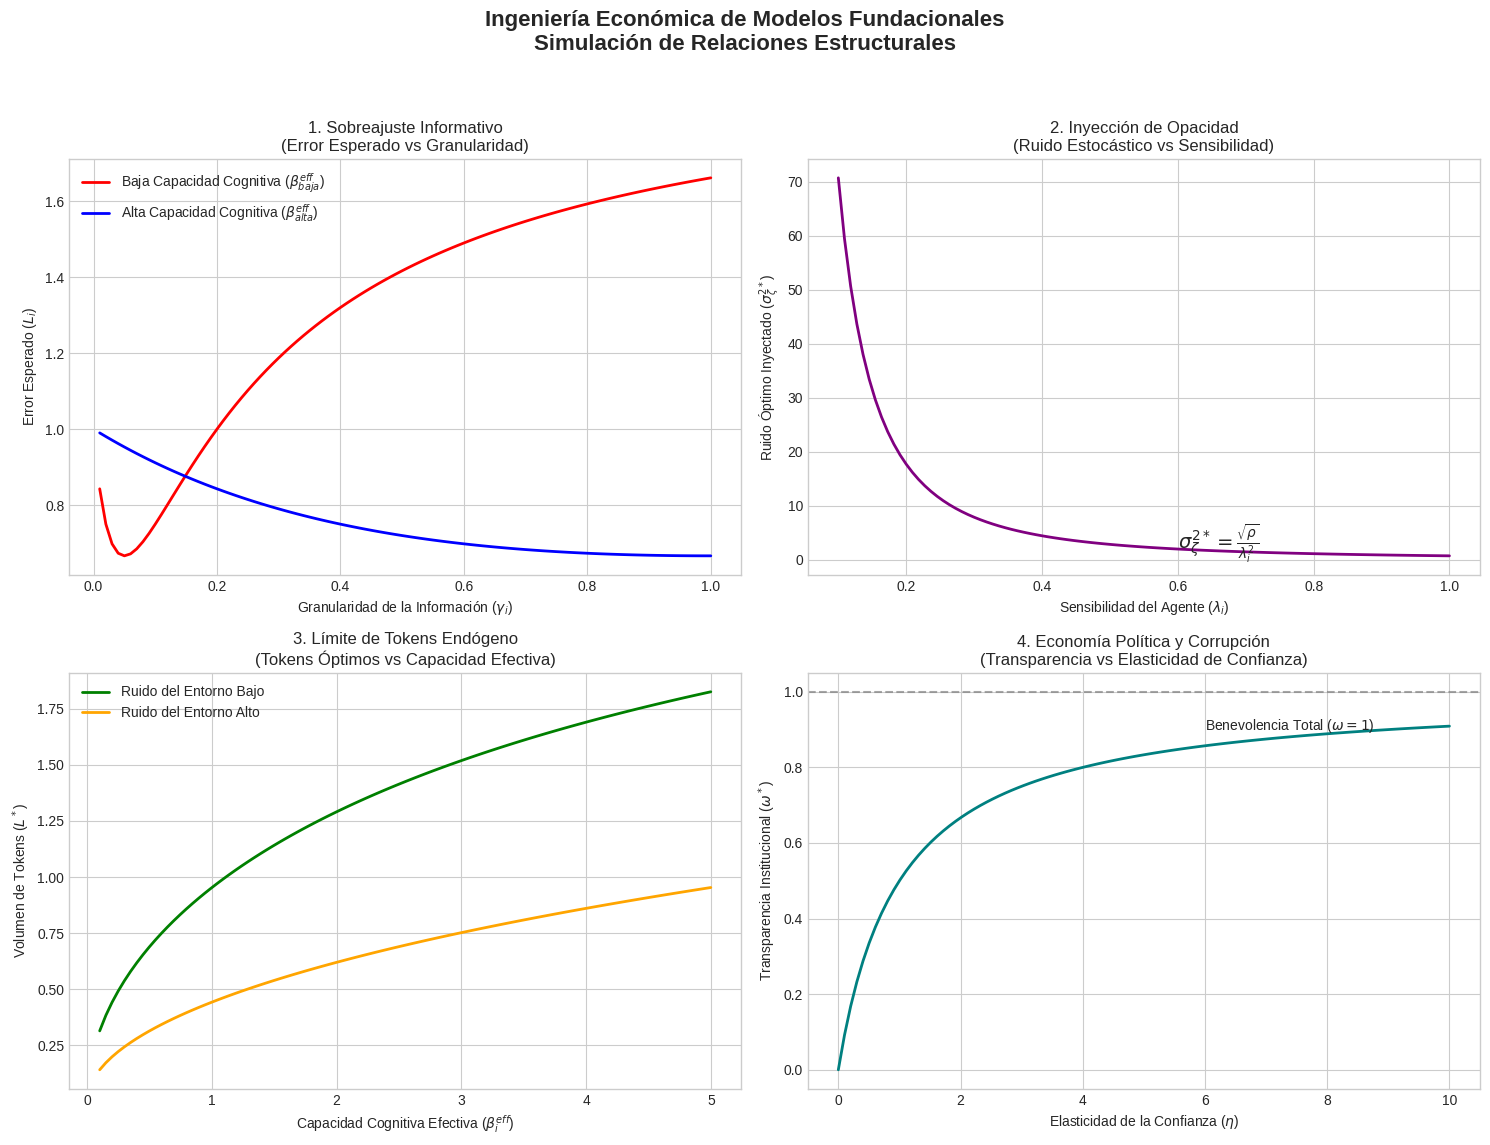

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Ingeniería Económica de Modelos Fundacionales\nSimulación de Relaciones Estructurales', fontsize=16, fontweight='bold')

# -------------------------------------------------------------------------
# 1. Teorema Fundamental del Sobreajuste Informativo (Error vs Granularidad)
# Ecuación: L_i = lambda_i^2 * sigma_s^2 + (1 - lambda_i)^2 * sigma_theta^2
# Axiomas: lambda_i aumenta con gamma_i y disminuye con beta_eff
# -------------------------------------------------------------------------
gamma = np.linspace(0.01, 1, 100) # Granularidad
sigma_s_sq = 2.0     # Varianza del ruido
sigma_theta_sq = 1.0 # Varianza de la tendencia estructural

# Función heurística para lambda que satisface los axiomas del texto
def calc_lambda(gamma, beta_eff):
    return gamma / (gamma + beta_eff)

beta_eff_low = 0.1   # Presión cognitiva alta
beta_eff_high = 2.0  # Capacidad cognitiva alta

lambda_low = calc_lambda(gamma, beta_eff_low)
lambda_high = calc_lambda(gamma, beta_eff_high)

error_low = (lambda_low**2)*sigma_s_sq + ((1 - lambda_low)**2)*sigma_theta_sq
error_high = (lambda_high**2)*sigma_s_sq + ((1 - lambda_high)**2)*sigma_theta_sq

axs[0, 0].plot(gamma, error_low, color='red', linewidth=2, label=r'Baja Capacidad Cognitiva ($\beta^{eff}_{baja}$)')
axs[0, 0].plot(gamma, error_high, color='blue', linewidth=2, label=r'Alta Capacidad Cognitiva ($\beta^{eff}_{alta}$)')
axs[0, 0].set_title('1. Sobreajuste Informativo\n(Error Esperado vs Granularidad)', fontsize=12)
axs[0, 0].set_xlabel(r'Granularidad de la Información ($\gamma_i$)')
axs[0, 0].set_ylabel(r'Error Esperado ($L_i$)')
axs[0, 0].legend()

# -------------------------------------------------------------------------
# 2. Inyección de Ruido Ortogonal (Opacidad vs Sensibilidad)
# Ecuación: sigma_zeta^2* = sqrt(rho) / lambda_i^2
# -------------------------------------------------------------------------
lambda_i = np.linspace(0.1, 1, 100) # Sensibilidad
rho = 0.5 # Aversión institucional a la homogeneidad

ruido_optimo = np.sqrt(rho) / (lambda_i**2)

axs[0, 1].plot(lambda_i, ruido_optimo, color='purple', linewidth=2)
axs[0, 1].set_title('2. Inyección de Opacidad\n(Ruido Estocástico vs Sensibilidad)', fontsize=12)
axs[0, 1].set_xlabel(r'Sensibilidad del Agente ($\lambda_i$)')
axs[0, 1].set_ylabel(r'Ruido Óptimo Inyectado ($\sigma_{\zeta}^{2*}$)')
axs[0, 1].annotate(r'$\sigma_{\zeta}^{2*} = \frac{\sqrt{\rho}}{\lambda_i^2}$', xy=(0.6, 2), fontsize=14)

# -------------------------------------------------------------------------
# 3. Óptimo Institucional: Límite de Tokens (L* vs Capacidad Cognitiva)
# Ecuación: L* = (k * sigma_theta^2) / sqrt((sigma_s^2 / beta_eff) + c)
# -------------------------------------------------------------------------
beta_eff_array = np.linspace(0.1, 5, 100)
k = 1.0 # Coeficiente de Aversión al Riesgo Estructural
c = 0.1 # Costo marginal computacional
sigma_s_sq_vals = [1.0, 5.0] # Diferentes niveles de ruido del entorno

for s_sq, color, label in zip(sigma_s_sq_vals, ['green', 'orange'], ['Ruido del Entorno Bajo', 'Ruido del Entorno Alto']):
    L_optimo = (k * sigma_theta_sq) / np.sqrt((s_sq / beta_eff_array) + c)
    axs[1, 0].plot(beta_eff_array, L_optimo, color=color, linewidth=2, label=label)

axs[1, 0].set_title('3. Límite de Tokens Endógeno\n(Tokens Óptimos vs Capacidad Efectiva)', fontsize=12)
axs[1, 0].set_xlabel(r'Capacidad Cognitiva Efectiva ($\beta_i^{eff}$)')
axs[1, 0].set_ylabel(r'Volumen de Tokens ($L^*$)')
axs[1, 0].legend()

# -------------------------------------------------------------------------
# 4. Economía Política (Transparencia vs Elasticidad de Confianza)
# Ecuación: omega* = eta / (eta + 1)
# -------------------------------------------------------------------------
eta = np.linspace(0, 10, 100) # Elasticidad de la confianza
omega_optimo = eta / (eta + 1)

axs[1, 1].plot(eta, omega_optimo, color='teal', linewidth=2)
axs[1, 1].set_title('4. Economía Política y Corrupción\n(Transparencia vs Elasticidad de Confianza)', fontsize=12)
axs[1, 1].set_xlabel(r'Elasticidad de la Confianza ($\eta$)')
axs[1, 1].set_ylabel(r'Transparencia Institucional ($\omega^*$)')
axs[1, 1].axhline(y=1, color='gray', linestyle='--', alpha=0.7)
axs[1, 1].text(6, 0.9, 'Benevolencia Total ($\omega=1$)', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()